# Exploratory Data Analysis (EDA)

This notebook now includes:
- Dataset overview
- Missingness analysis
- Class/label distribution
- Feature summaries
- Key visualizations
- Interpretation of findings with concrete preprocessing and modeling implications

In [1]:
# Setup and data loading
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

print('Loading dataset from OpenML (data_id=42972)...')
data = fetch_openml(data_id=42972, as_frame=True, parser='auto')
df = data.frame.copy()

candidate_targets = []
if hasattr(data, 'target_names') and data.target_names:
    candidate_targets.extend(data.target_names)
if hasattr(data, 'target') and hasattr(data.target, 'name') and data.target.name:
    candidate_targets.append(data.target.name)
candidate_targets.extend(['classification', 'class', 'target', 'label', 'y'])
target_col = next((col for col in candidate_targets if col in df.columns), None)

if target_col is None:
    raise ValueError('Could not detect target column. Please set target_col manually.')

print(f'Dataset shape: {df.shape}')
print(f'Detected target column: {target_col}')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in df.columns if c != target_col]
numeric_feature_cols = [c for c in numeric_cols if c != target_col]

print(f'Number of feature columns: {len(feature_cols)}')
print(f'Numeric feature columns: {len(numeric_feature_cols)}')

Loading dataset from OpenML (data_id=42972)...
Dataset shape: (400, 26)
Detected target column: classification
Number of feature columns: 25
Numeric feature columns: 12


## Dataset Overview and Missingness Analysis



,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


Column-level overview (sorted by missingness):


,dtype,non_null_count,missing_count,missing_pct
rbc,str,248,152,38.00
rc,str,270,130,32.50
wc,str,295,105,26.25
pot,float64,312,88,22.00
sod,float64,313,87,21.75
pcv,str,330,70,17.50
pc,str,335,65,16.25
hemo,float64,348,52,13.00
su,float64,351,49,12.25
sg,float64,353,47,11.75


Dataset-level missingness summary:
- Total missing values: 1009
- Percent missing cells: 9.70%
- Columns with at least one missing value: 24


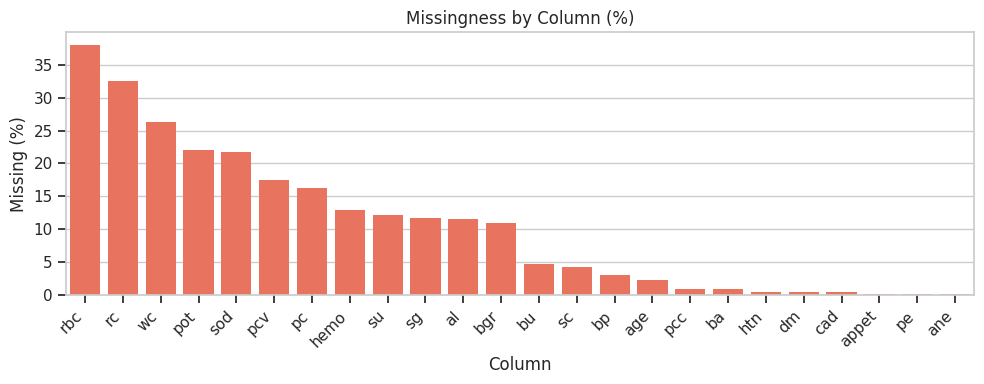

In [2]:
# Dataset overview + missingness analysis
display(df.head())

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'missing_count': df.isna().sum()
})
overview['missing_pct'] = (overview['missing_count'] / len(df) * 100).round(2)
overview = overview.sort_values(['missing_pct', 'missing_count'], ascending=False)

print('Column-level overview (sorted by missingness):')
display(overview)

print('Dataset-level missingness summary:')
total_cells = df.shape[0] * df.shape[1]
total_missing = int(df.isna().sum().sum())
print(f'- Total missing values: {total_missing}')
print(f'- Percent missing cells: {100 * total_missing / total_cells:.2f}%')

missing_cols = overview[overview['missing_count'] > 0].index.tolist()
print(f'- Columns with at least one missing value: {len(missing_cols)}')

# Visualize missingness by column when present
if len(missing_cols) > 0:
    plt.figure(figsize=(10, 4))
    miss_plot = overview.loc[missing_cols, 'missing_pct'].sort_values(ascending=False)
    sns.barplot(x=miss_plot.index, y=miss_plot.values, color='tomato')
    plt.title('Missingness by Column (%)')
    plt.xlabel('Column')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values detected.')

## Label Distribution, Feature Summaries, and Key Visualizations

Label distribution:


,count,pct
classification,,
ckd,248,62.0
notckd,150,37.5
'ckdt',2,0.5


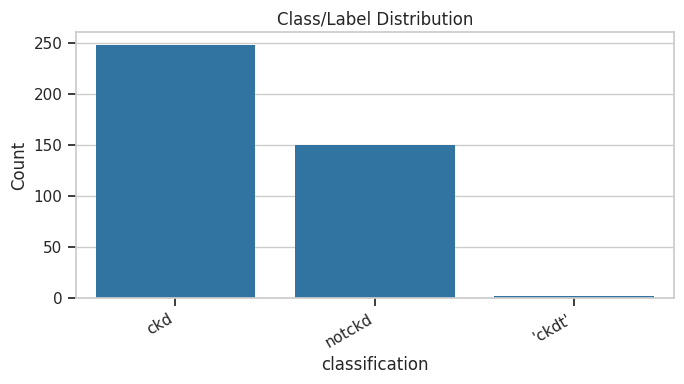

Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
id,400.0,199.500,115.614,0.000,99.75,199.50,299.25,399.000,0.000,-1.200
age,391.0,51.483,17.170,2.000,42.00,55.00,64.50,90.000,-0.668,0.058
bp,388.0,76.469,13.684,50.000,70.00,80.00,80.00,180.000,1.605,8.646
sg,353.0,1.017,0.006,1.005,1.01,1.02,1.02,1.025,-0.172,-1.144
al,354.0,1.017,1.353,0.000,0.00,0.00,2.00,5.000,0.998,-0.383
su,351.0,0.450,1.099,0.000,0.00,0.00,0.00,5.000,2.464,5.055
bgr,356.0,148.037,79.282,22.000,99.00,121.00,163.00,490.000,2.011,4.226
bu,381.0,57.426,50.503,1.500,27.00,42.00,66.00,391.000,2.634,9.345
sc,383.0,3.072,5.741,0.400,0.90,1.30,2.80,76.000,7.510,79.304
sod,313.0,137.529,10.409,4.500,135.00,138.00,142.00,163.000,-6.997,85.534


Categorical feature summary:


,n_unique,most_common
wc,93,NaN
rc,50,NaN
pcv,45,NaN
dm,6,no
cad,4,no
ba,3,notpresent
pcc,3,notpresent
pc,3,normal
rbc,3,normal
htn,3,no


In [3]:
# Class/label distribution + feature summaries
label_counts = df[target_col].value_counts(dropna=False)
label_pct = (label_counts / len(df) * 100).round(2)
label_summary = pd.DataFrame({'count': label_counts, 'pct': label_pct})

print('Label distribution:')
display(label_summary)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_col, order=label_counts.index)
plt.title('Class/Label Distribution')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

if numeric_feature_cols:
    numeric_summary = df[numeric_feature_cols].describe().T
    numeric_summary['skew'] = df[numeric_feature_cols].skew(numeric_only=True)
    numeric_summary['kurtosis'] = df[numeric_feature_cols].kurtosis(numeric_only=True)
    print('Numeric feature summary:')
    display(numeric_summary.round(3))
else:
    print('No numeric feature columns for summary statistics.')

categorical_feature_cols = [c for c in feature_cols if c not in numeric_feature_cols]
if categorical_feature_cols:
    cat_cardinality = pd.DataFrame({
        'n_unique': df[categorical_feature_cols].nunique(dropna=False),
        'most_common': [df[c].mode(dropna=False).iloc[0] if not df[c].mode(dropna=False).empty else np.nan for c in categorical_feature_cols]
    }).sort_values('n_unique', ascending=False)
    print('Categorical feature summary:')
    display(cat_cardinality)

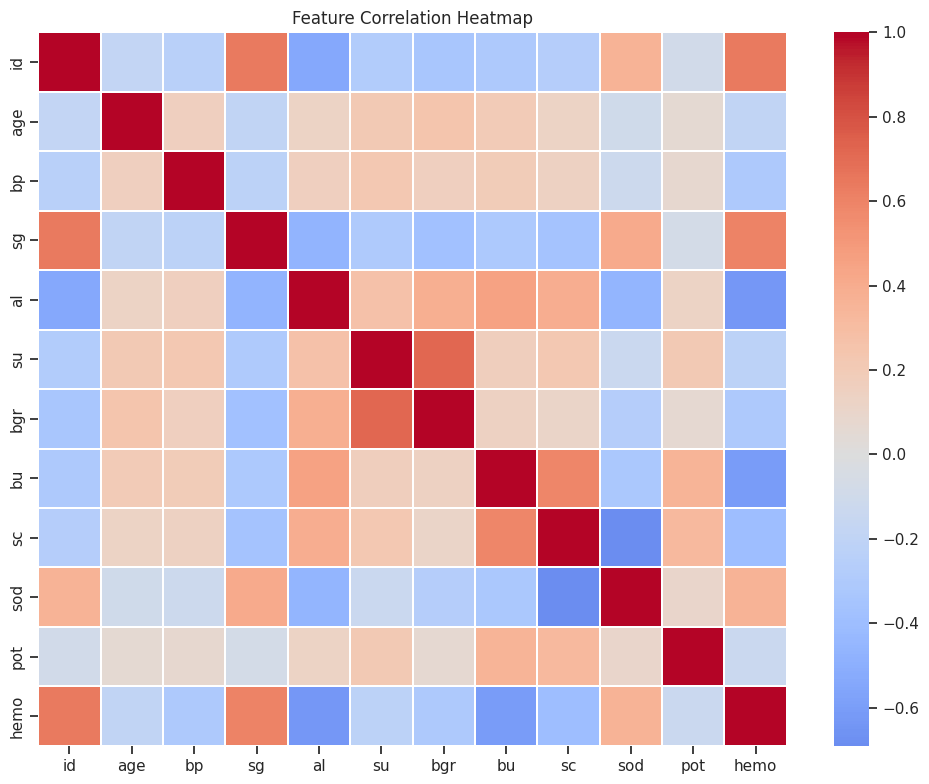

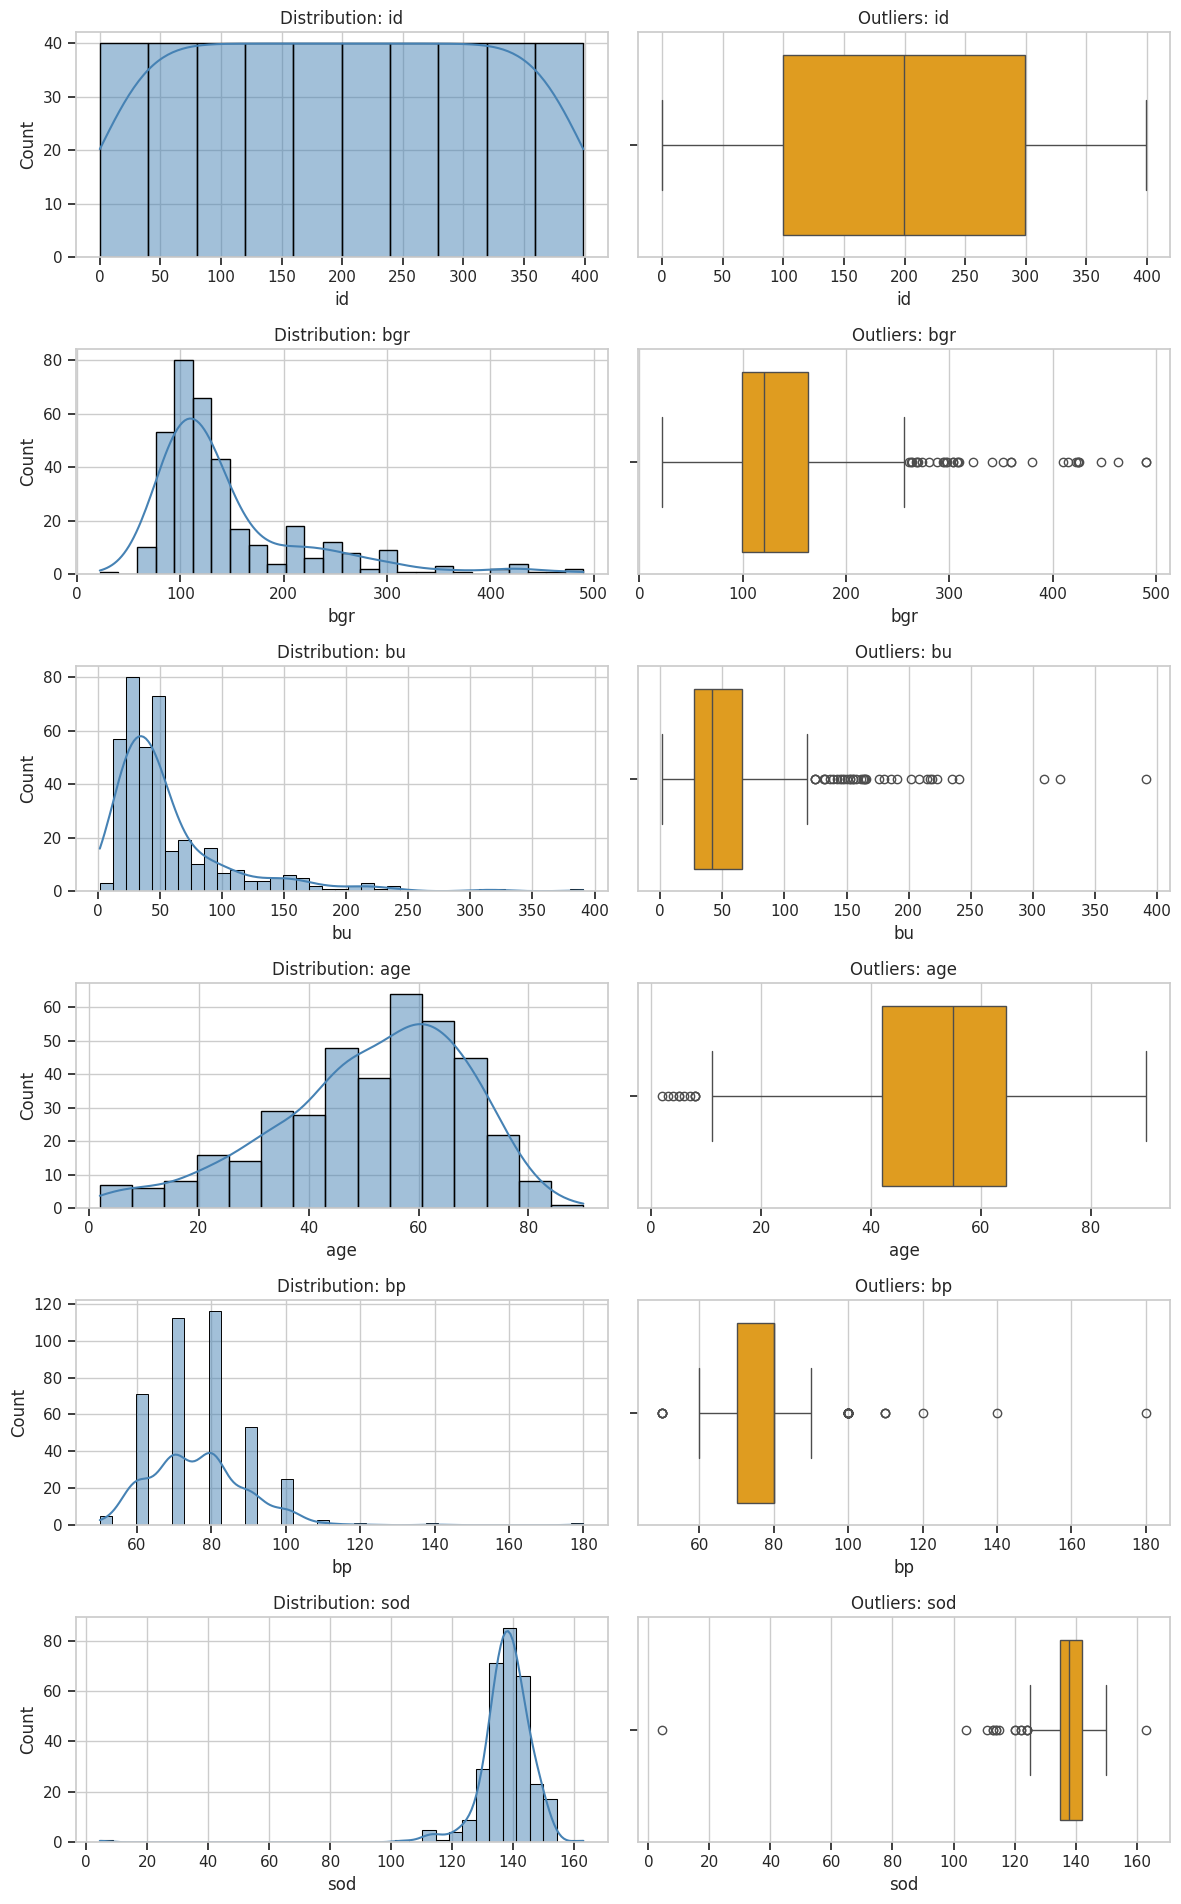

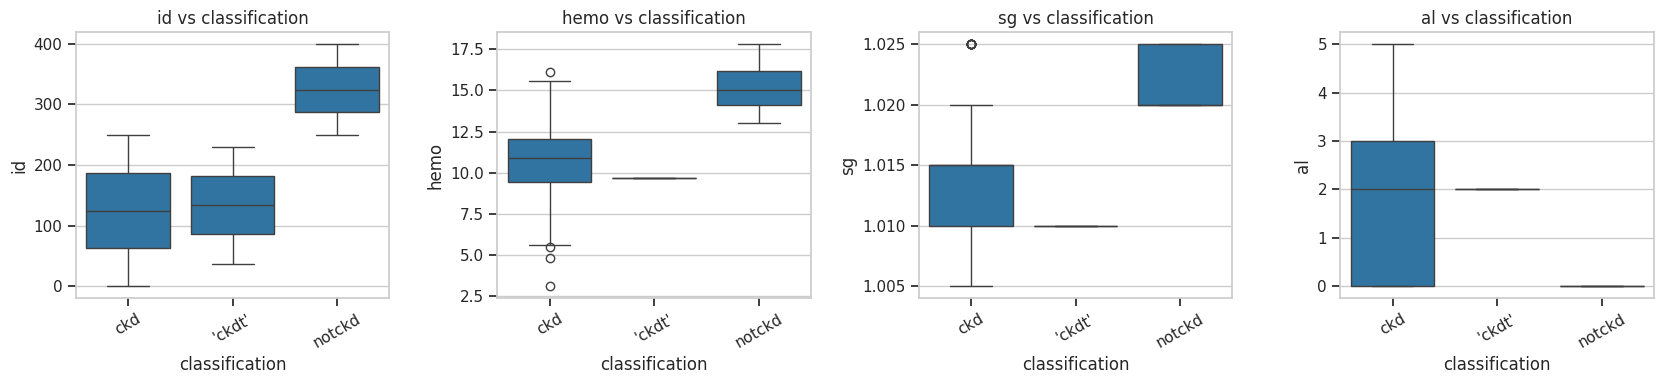

EDA-driven interpretation and modeling implications:
- Missingness exists (max 38.00% in "rbc"): apply imputation in a pipeline (median for numeric, mode for categorical).
- Class imbalance detected (major/minor ratio 124.00): use stratified split, class weights, and macro-F1 or balanced accuracy.
- 7 numeric features are strongly skewed (|skew| > 1): consider robust scaling and/or power/log transforms.
- Limited multicollinearity at |r| > 0.85: broad model families remain viable.

Suggested baseline model strategy:
- Start with a stratified train/validation split.
- Compare a regularized linear model (interpretable baseline) with a tree-based ensemble (nonlinear baseline).
- Use preprocessing in a single pipeline to avoid leakage and ensure reproducibility.


In [4]:
# Key visualizations + interpretation of findings
if numeric_feature_cols:
    # Correlation heatmap
    corr = df[numeric_feature_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Distribution and outlier visuals for top features with highest variance
    top_k = min(6, len(numeric_feature_cols))
    top_var_features = df[numeric_feature_cols].var().sort_values(ascending=False).head(top_k).index.tolist()

    fig, axes = plt.subplots(top_k, 2, figsize=(12, 3.2 * top_k))
    if top_k == 1:
        axes = np.array([axes])

    for i, col in enumerate(top_var_features):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='steelblue')
        axes[i, 0].set_title(f'Distribution: {col}')

        sns.boxplot(x=df[col], ax=axes[i, 1], color='orange')
        axes[i, 1].set_title(f'Outliers: {col}')

    plt.tight_layout()
    plt.show()

    # Relationship-to-target visualization for top numeric features
    target_as_str = df[target_col].astype(str)
    box_k = min(4, len(numeric_feature_cols))
    top_abs_corr = (
        df[numeric_feature_cols + [target_col]]
        .assign(**{target_col: pd.Categorical(target_as_str).codes})
        [numeric_feature_cols + [target_col]]
        .corr()[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending=False)
        .head(box_k)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(1, box_k, figsize=(4.2 * box_k, 4), squeeze=False)
    for i, col in enumerate(top_abs_corr):
        sns.boxplot(data=df, x=target_col, y=col, ax=axes[0, i])
        axes[0, i].set_title(f'{col} vs {target_col}')
        axes[0, i].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

# Interpretation: convert EDA observations into preprocessing and model-design choices
print('EDA-driven interpretation and modeling implications:')
recommendations = []

missing_pct = (df.isna().sum() / len(df) * 100)
if missing_pct.max() > 0:
    max_col = missing_pct.idxmax()
    max_val = float(missing_pct.max())
    recommendations.append(
        f'- Missingness exists (max {max_val:.2f}% in "{max_col}"): apply imputation in a pipeline (median for numeric, mode for categorical).'
    )
else:
    recommendations.append('- No missingness detected: imputation may be optional but still keep a robust pipeline step.')

imbalance_ratio = label_counts.max() / label_counts.min() if len(label_counts) > 1 else 1.0
if imbalance_ratio >= 1.5:
    recommendations.append(
        f'- Class imbalance detected (major/minor ratio {imbalance_ratio:.2f}): use stratified split, class weights, and macro-F1 or balanced accuracy.'
    )
else:
    recommendations.append('- Class distribution appears reasonably balanced: standard stratified evaluation is likely sufficient.')

if numeric_feature_cols:
    skew_abs = df[numeric_feature_cols].skew(numeric_only=True).abs()
    high_skew = skew_abs[skew_abs > 1.0]
    if len(high_skew) > 0:
        recommendations.append(
            f'- {len(high_skew)} numeric features are strongly skewed (|skew| > 1): consider robust scaling and/or power/log transforms.'
        )
    else:
        recommendations.append('- Most numeric features show limited skew: standard scaling may be enough.')

    corr_pairs = []
    if len(numeric_feature_cols) > 1:
        c = df[numeric_feature_cols].corr().abs()
        for i in range(len(c.columns)):
            for j in range(i + 1, len(c.columns)):
                if c.iloc[i, j] > 0.85:
                    corr_pairs.append((c.index[i], c.columns[j], c.iloc[i, j]))
    if corr_pairs:
        recommendations.append(
            f'- Strong multicollinearity found ({len(corr_pairs)} pairs with |r| > 0.85): prefer regularization, feature selection, or tree-based models.'
        )
    else:
        recommendations.append('- Limited multicollinearity at |r| > 0.85: broad model families remain viable.')

for rec in recommendations:
    print(rec)

print('\nSuggested baseline model strategy:')
print('- Start with a stratified train/validation split.')
print('- Compare a regularized linear model (interpretable baseline) with a tree-based ensemble (nonlinear baseline).')
print('- Use preprocessing in a single pipeline to avoid leakage and ensure reproducibility.')